<a href="https://colab.research.google.com/github/sonjoy1s/ML/blob/main/Cyber_Security_Attack_Using_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
df = pd.read_csv("/content/cyber_attack_dataset_100000.csv")
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,PortScan
99996,2,153,146,85,TCP,0,PortScan
99997,37,161,114,61,UDP,10,BruteForce
99998,4,142,69,73,TCP,0,PortScan


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   duration       100000 non-null  int64 
 1   src_bytes      100000 non-null  int64 
 2   dst_bytes      100000 non-null  int64 
 3   packet_count   100000 non-null  int64 
 4   protocol       100000 non-null  object
 5   failed_logins  100000 non-null  int64 
 6   attack_type    100000 non-null  object
dtypes: int64(5), object(2)
memory usage: 5.3+ MB


In [32]:
df.columns

Index(['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'protocol',
       'failed_logins', 'attack_type'],
      dtype='object')

In [33]:
df.shape[0]

100000

In [34]:
df.shape[1]

7

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,100000.0,16.46272,15.632207,1.0,4.0,10.0,28.0,60.0
src_bytes,100000.0,2219.62870,2751.142410,50.0,341.0,781.0,3024.0,10000.0
dst_bytes,100000.0,426.17103,466.528205,20.0,131.0,256.0,458.0,2000.0
packet_count,100000.0,202.55077,249.729802,5.0,37.0,87.0,257.0,1000.0
failed_logins,100000.0,1.63052,3.045577,0.0,0.0,0.0,3.0,10.0


In [36]:
df.isna().sum()

,0
duration,0
src_bytes,0
dst_bytes,0
packet_count,0
protocol,0
failed_logins,0
attack_type,0


In [37]:
df.nunique()

,0
duration,60
src_bytes,9739
dst_bytes,1981
packet_count,996
protocol,2
failed_logins,9
attack_type,4


In [38]:
df.head()

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce


In [39]:
df['attack_type'].unique()

array(['DDoS', 'PortScan', 'BruteForce', 'Normal'], dtype=object)

In [40]:
le = LabelEncoder()
df['attack_type'] = le.fit_transform(df['attack_type'])
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,1
1,1,499,148,131,UDP,0,3
2,10,370,160,105,UDP,0,3
3,2,5138,320,666,TCP,0,1
4,36,524,467,58,UDP,10,0
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,3
99996,2,153,146,85,TCP,0,3
99997,37,161,114,61,UDP,10,0
99998,4,142,69,73,TCP,0,3


In [41]:
X = df.drop(columns=['attack_type'],axis=1)
y = df['attack_type']

In [42]:
numerical_cols = X.select_dtypes(include=np.number).columns
print(numerical_cols)

categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['duration', 'src_bytes', 'dst_bytes', 'packet_count', 'failed_logins'], dtype='object')
Index(['protocol'], dtype='object')


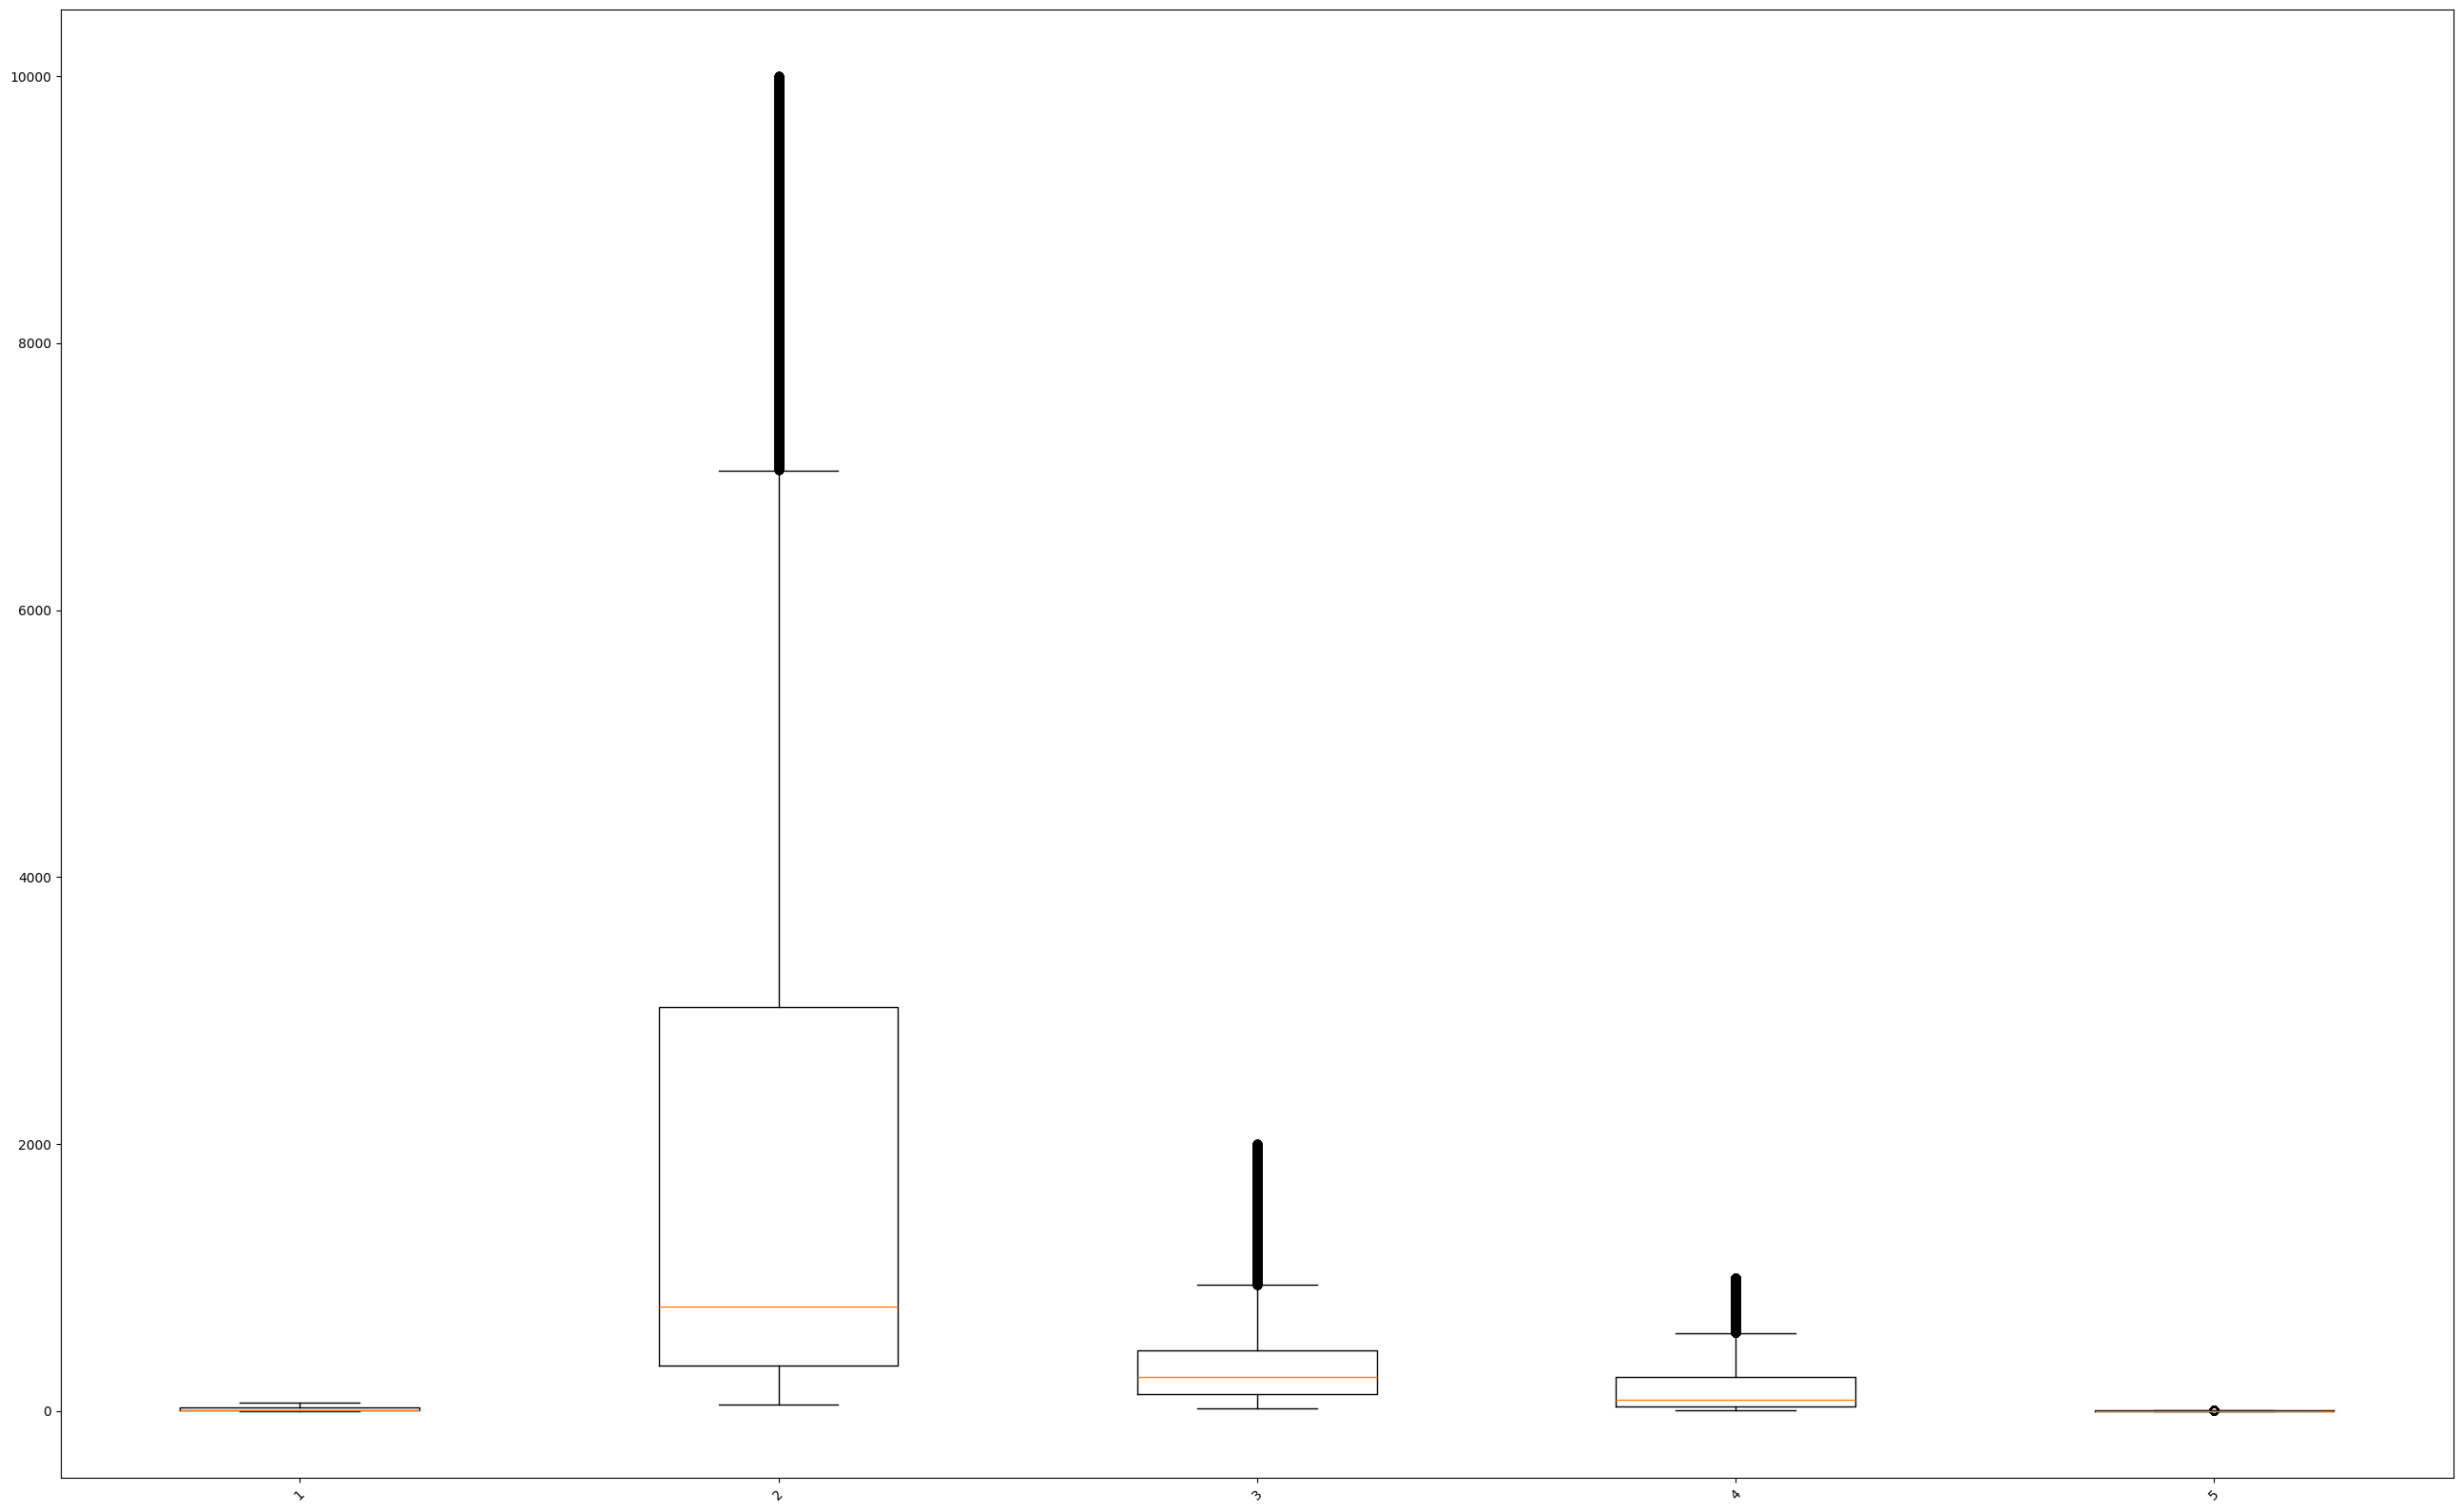

In [43]:
plt.figure(figsize=(26,16))
plt.boxplot(df[numerical_cols])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

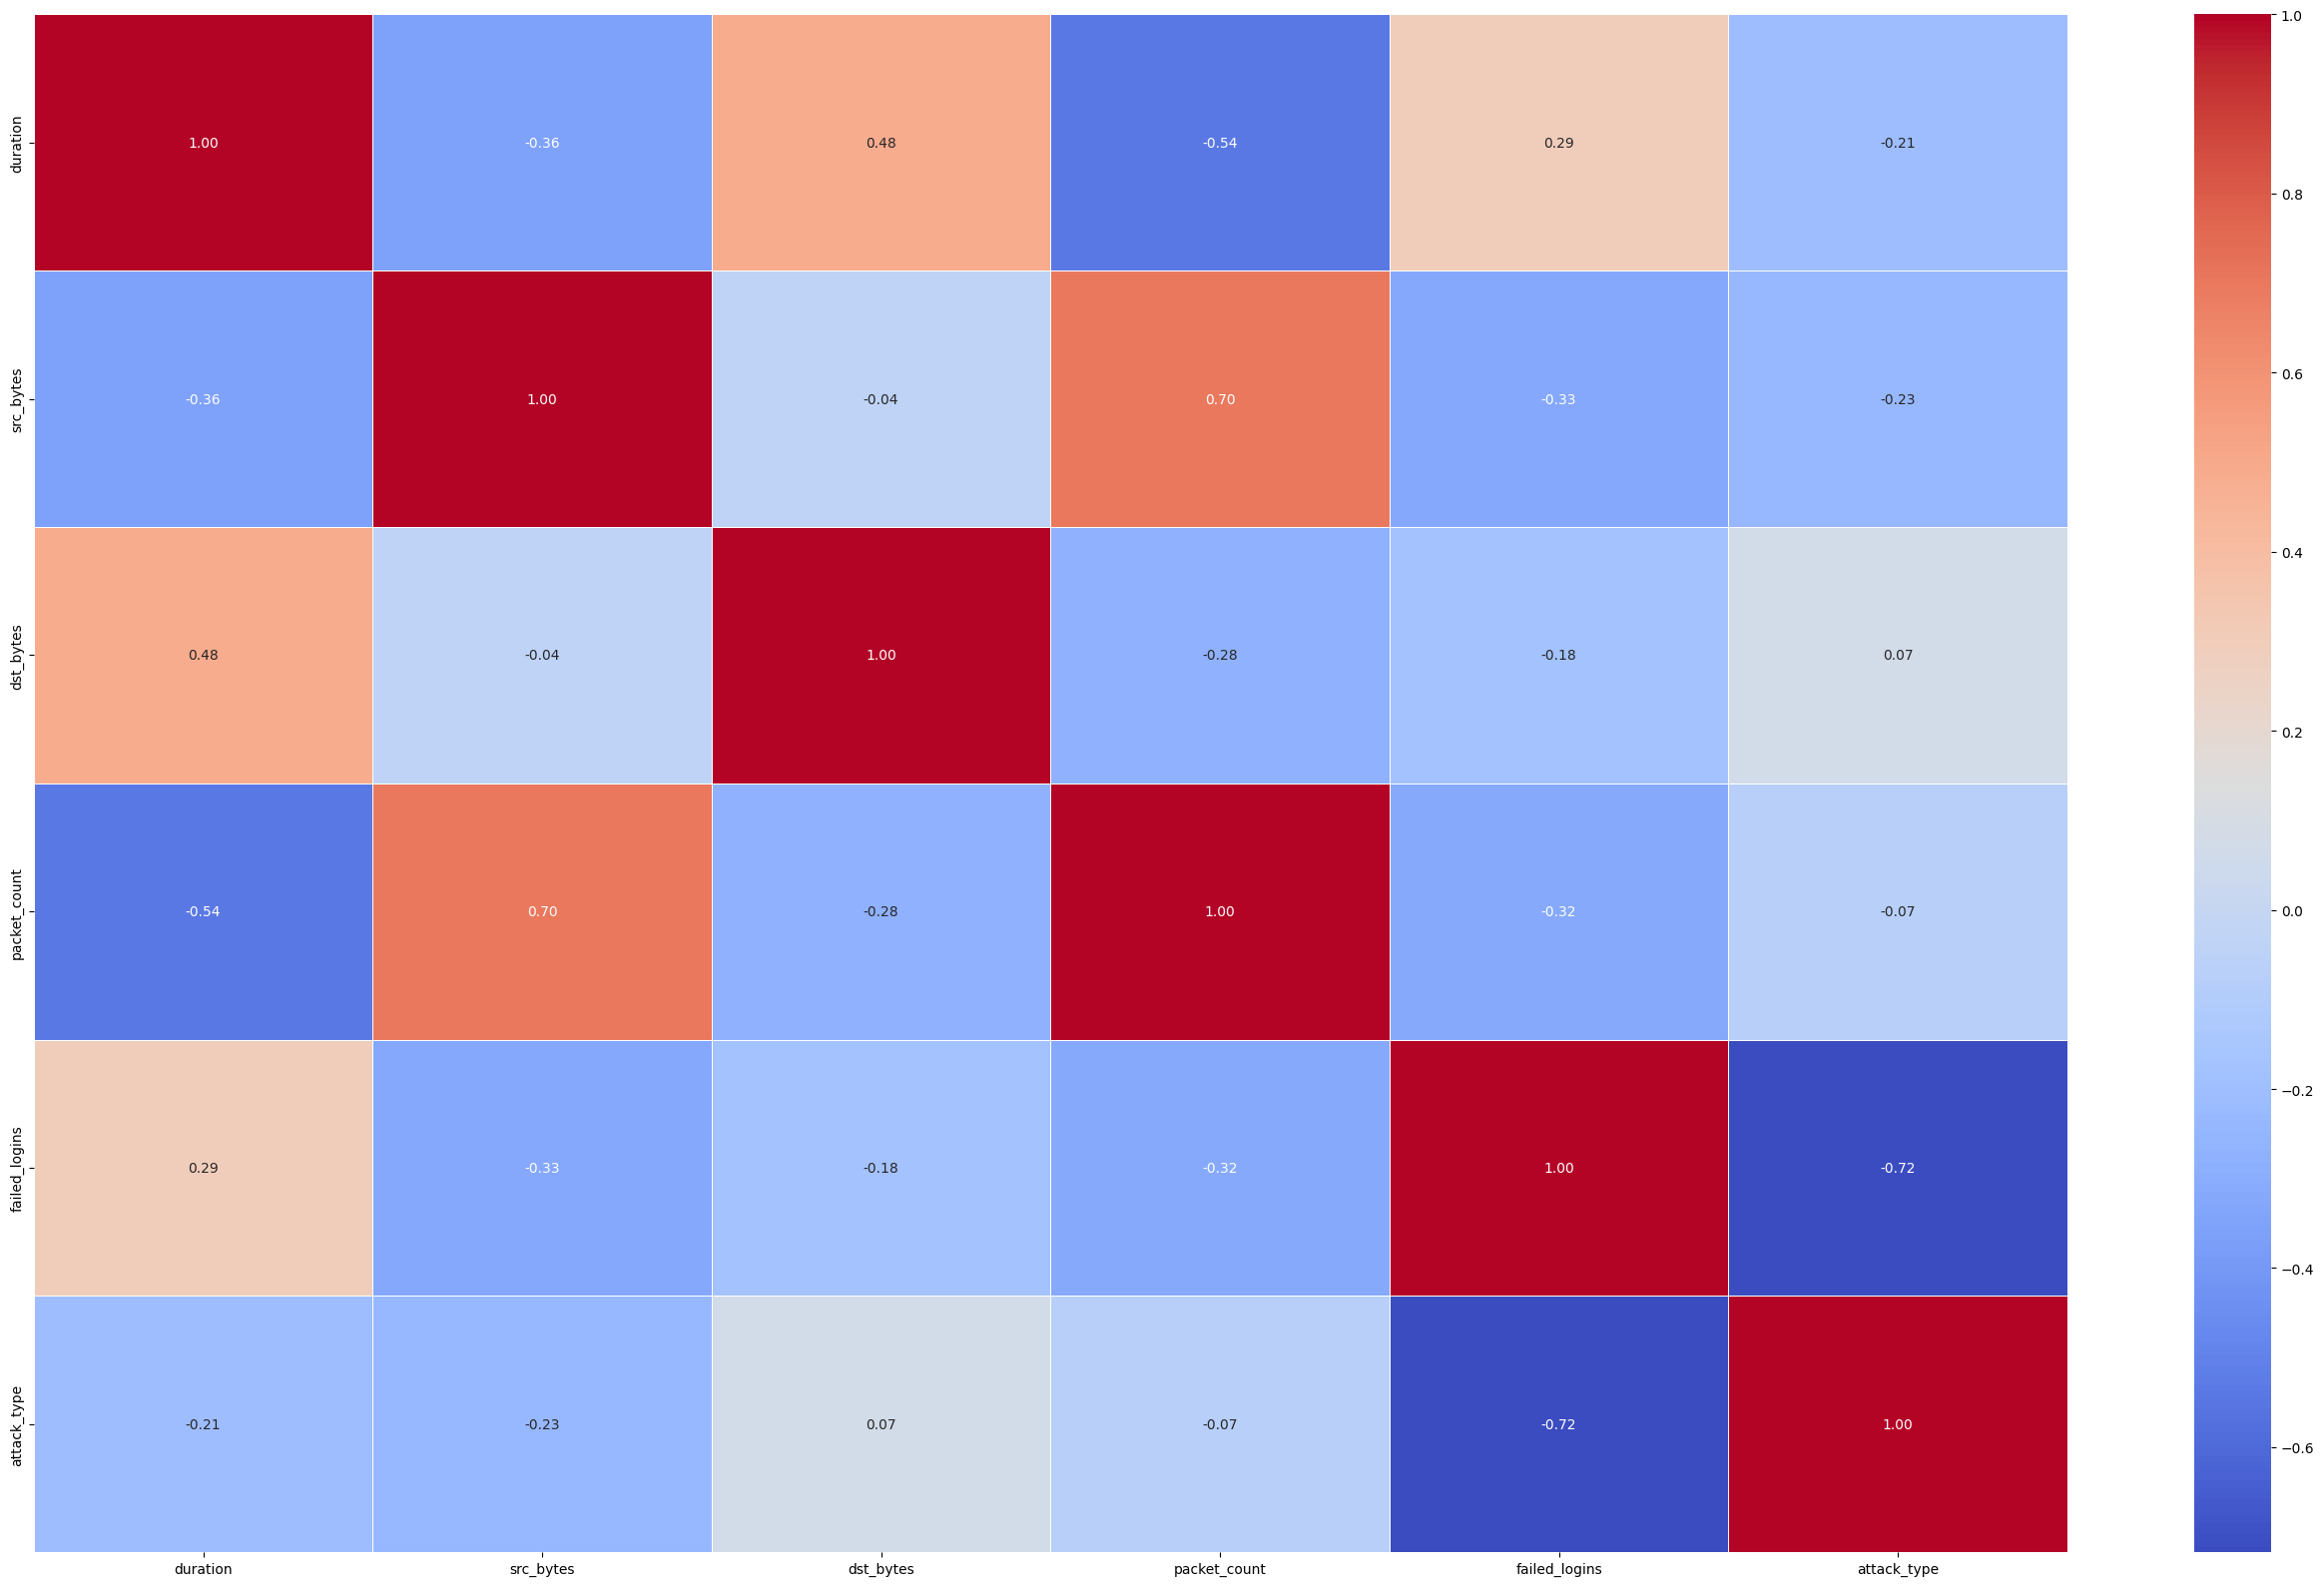

In [45]:
target_col ='attack_type'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.tight_layout()
plt.show()